In [41]:
import wandb
import pandas as pd
import numpy as np
import seaborn as sns

from matplotlib import pyplot as plt
%matplotlib inline

In [42]:
api = wandb.Api()

In [43]:
runs = api.runs(path="harvardml/opt-olmo")

In [44]:
optimizers = ['sgdw', 'adamw', 'novagradw_ours', 'adafactorw', 'lionw', 'signsgd',  'sophiag',] 
display_names = ['SGD', 'Adam',  'NovoGrad', 'Adafactor', 'Lion', 'Signum', 'Sophia G',]
colors = sns.color_palette('Set2', n_colors=len(optimizers))

color_map = dict(zip(optimizers, colors))
name_map = dict(zip(optimizers, display_names))

In [49]:
df = pd.DataFrame()

steps = [100, 300, 500, 900, 1700, 2900, 4900, 8500, 14600, 25000]
step = 25000
groups = ["momentum-all-1", "momentum-300-1", "momentum-llama-lite-2", "momentum-llama-lite-3",
          "momentum-150-damped-1", "momentum-150-noqk-damped-1", "momentum-300-damped-1"]

for run in runs:
    if run.group in groups:
        history = run.history(samples=25000, 
                        keys=[
                            "eval/c4_val/CrossEntropyLoss", 
                            "train/CrossEntropyLoss", 
                            "optim/total_grad_norm",
                            ])
        
        if "300" in run.group:
            step = 50000
        else:
            step = 25000
    
        run_dict = {}
        run_dict["id"] = run.id
        run_dict["group"] = run.group

        if "lite" in run.group:
            run_dict["group"] = "momentum-noqk-1"
        
        # Only include damped runs for sgdw
        # if "damped" not in run.group and run.config["optimizer"]["name"] == "sgdw":
        #     continue
        # if "noqk" in run.group:
        #     run_dict["group"] = "momentum-noqk-1"
        # if run.group == "momentum-150-damped-1":
        #     run_dict["group"] = "momentum-all-1"
        # if run.group == "momentum-300-damped-1":
        #     run_dict["group"] = "momentum-300-1"

        run_dict["optimizer"] = run.config["optimizer"]["name"]
        run_dict["learning_rate"] = run.config["optimizer"]["learning_rate"]
        run_dict["beta_0"] = run.config["optimizer"]["beta_0"]
        run_dict["beta_1"] = run.config["optimizer"]["beta_1"]
        run_dict["eps"] = run.config["optimizer"]["eps"]
        if "eval/c4_val/CrossEntropyLoss" in history:
            if step not in list(history["_step"]):
                run_dict["val_loss"] = 10.0
            else:
                run_dict["val_loss"] = list(history[history["_step"] == step]["eval/c4_val/CrossEntropyLoss"])[0]
                run_dict["step"] = step
        else:
            run_dict["val_loss"] = np.nan
            run_dict["step"] = np.nan
        if run_dict["optimizer"] == "novagradw" and run.config["optimizer"]["att_correction"]:
            run_dict["optimizer"] = "novagradw_ours"
        if (run_dict["optimizer"] == "adafactorw" and 
            "neuron_only" in run.config["optimizer"] and
            run.config["optimizer"]["neuron_only"]
        ):
            run_dict["optimizer"] = "adafactorw_oneside"
        run_df = pd.DataFrame(run_dict, index=[0])
        df = pd.concat([df, run_df])

In [50]:
df

,id,group,optimizer,learning_rate,beta_0,beta_1,eps,val_loss,step
0,nk6dvwmk,momentum-300-damped-1,sgdw,31.600000,0.50,0.95,1.000000e-15,6.331638,50000.0
0,b0otz6cz,momentum-300-damped-1,sgdw,31.600000,0.90,0.95,1.000000e-15,5.782654,50000.0
0,9zvmt8vt,momentum-300-damped-1,sgdw,31.600000,0.80,0.95,1.000000e-15,3.109915,50000.0
0,3ze2fcck,momentum-300-damped-1,sgdw,31.600000,0.00,0.95,1.000000e-15,5.832637,50000.0
0,l1kdnlpk,momentum-300-damped-1,sgdw,31.600000,0.99,0.95,1.000000e-15,3.013074,50000.0
...,...,...,...,...,...,...,...,...,...
0,6h93lc9b,momentum-all-1,lionw,0.000316,0.80,0.95,1.000000e-15,3.088297,25000.0
0,02v4uzxk,momentum-all-1,signsgd,0.000316,0.95,0.95,1.000000e-15,3.072563,25000.0
0,qaju3tdr,momentum-all-1,sgdw,1.000000,0.90,0.95,1.000000e-15,3.297276,25000.0
0,6lrm4evq,momentum-all-1,sgdw,1.000000,0.80,0.95,1.000000e-15,3.402063,25000.0


In [51]:
df[df["optimizer"] == "sgdw"]

,id,group,optimizer,learning_rate,beta_0,beta_1,eps,val_loss,step
0,nk6dvwmk,momentum-300-damped-1,sgdw,31.6000,0.500,0.95,1.000000e-15,6.331638,50000.0
0,b0otz6cz,momentum-300-damped-1,sgdw,31.6000,0.900,0.95,1.000000e-15,5.782654,50000.0
0,9zvmt8vt,momentum-300-damped-1,sgdw,31.6000,0.800,0.95,1.000000e-15,3.109915,50000.0
0,3ze2fcck,momentum-300-damped-1,sgdw,31.6000,0.000,0.95,1.000000e-15,5.832637,50000.0
0,l1kdnlpk,momentum-300-damped-1,sgdw,31.6000,0.990,0.95,1.000000e-15,3.013074,50000.0
0,3h1xkqgj,momentum-300-damped-1,sgdw,31.6000,0.980,0.95,1.000000e-15,2.987571,50000.0
0,14xgbvzo,momentum-300-damped-1,sgdw,31.6000,0.950,0.95,1.000000e-15,2.993980,50000.0
0,ju9xf76r,momentum-150-noqk-damped-1,sgdw,31.6000,0.980,0.95,1.000000e-15,3.210419,25000.0
0,6mv2d0ac,momentum-150-noqk-damped-1,sgdw,31.6000,0.950,0.95,1.000000e-15,3.368713,25000.0
0,052tpe4r,momentum-150-noqk-damped-1,sgdw,31.6000,0.990,0.95,1.000000e-15,3.295154,25000.0


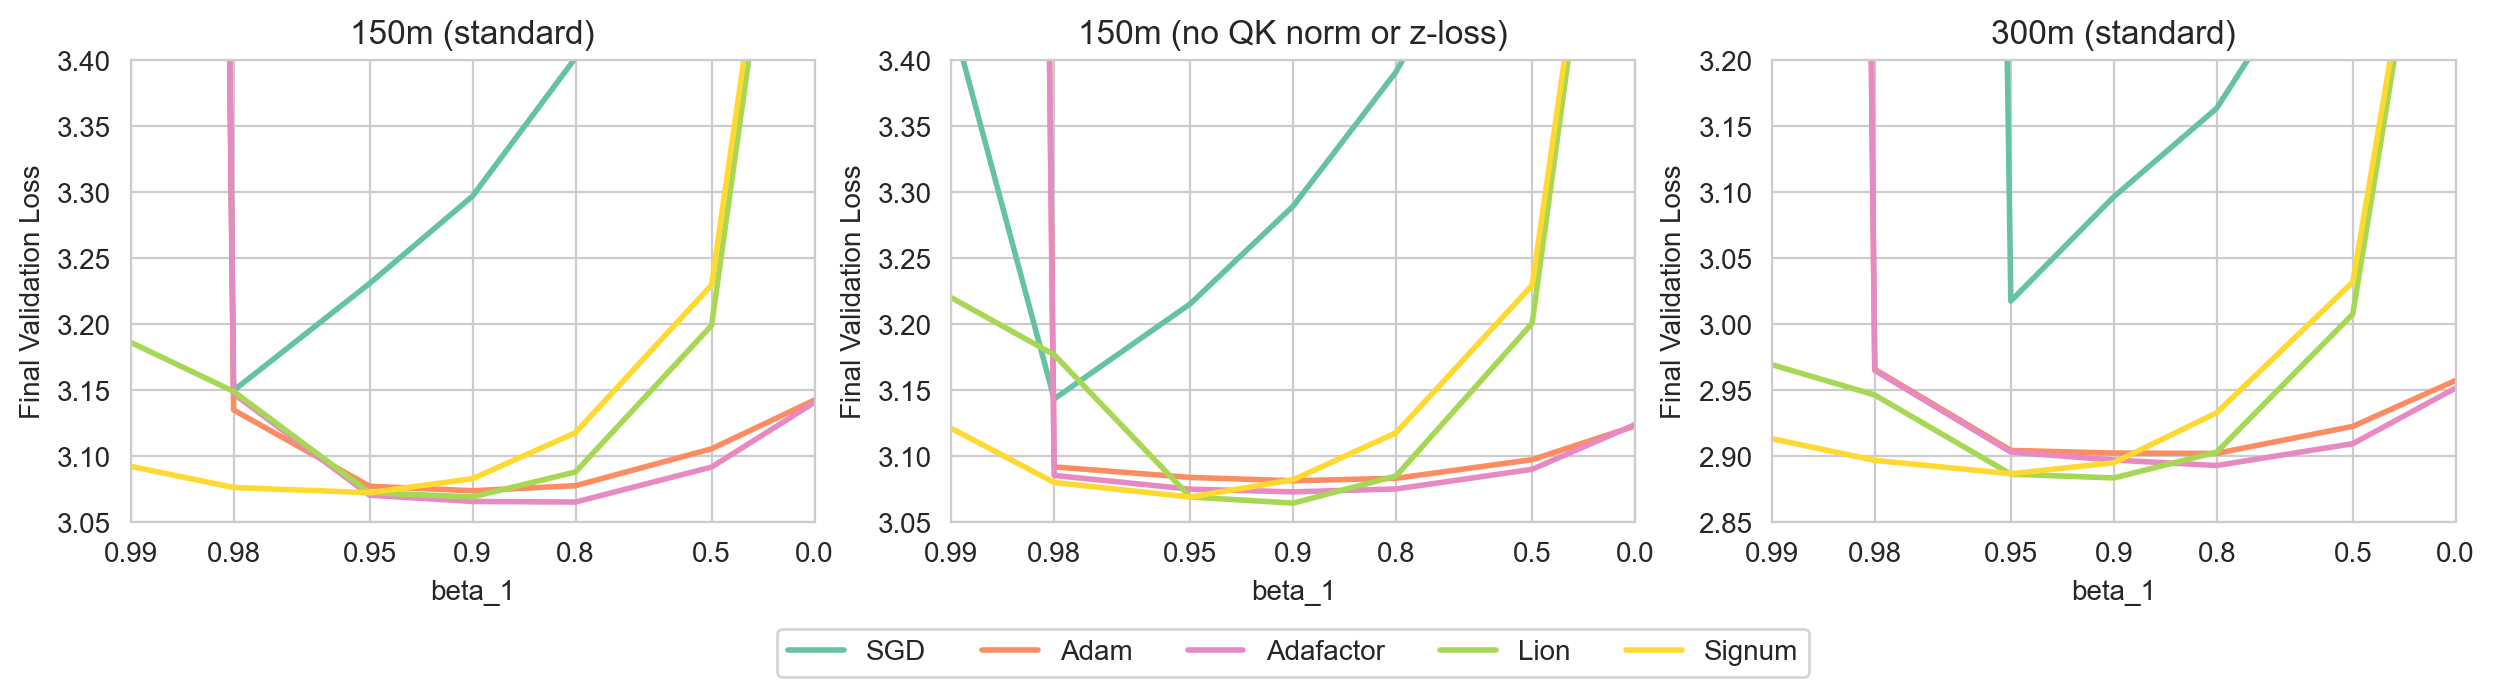

In [52]:
sns.set_style("whitegrid")
#plt.figure(figsize=(15, 3), dpi=200)  # Larger figure size
fig, axs = plt.subplots(1, 3, figsize=(15, 3), dpi=200)

for i, group in enumerate(["momentum-all-1", "momentum-noqk-1", "momentum-300-1"]):

    ax = axs[i]
    group_df = df[df["group"] == group]

    for optimizer in optimizers:
        if optimizer in ["sophiag", "novagradw_ours"]:
            continue
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by="beta_0")
            optimizer_df = optimizer_df.groupby("beta_0").min().reset_index()
            label = name_map.get(optimizer)
            ax.plot(1 - optimizer_df["beta_0"], 
                    optimizer_df["val_loss"], 
                    label=label,
                    linewidth=2,
                    color=color_map[optimizer],
                    # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
            )
            # if optimizer in ["lionw"]:
            #     optimizer_df = df[(df["group"] == "beta-all-1") & (df["optimizer"] == "lionw")]
            #     optimizer_df = optimizer_df.sort_values(by="beta_1")
            #     optimizer_df = optimizer_df.groupby("beta_1").min().reset_index()
            #     label = "Lion (beta 2)"
            #     plt.plot(1 - optimizer_df["beta_1"], 
            #             optimizer_df["val_loss"], 
            #             label=label,
            #             linewidth=2,
            #             color=color_map["lionw"],
            #             linestyle=':',
            #     )


    ax.set_xscale("log")
    ax.set_xlim(0.01, 1)

    ax.set_xlabel("beta_1")
    xs = [0.0, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99][::-1]

    xsa = 1 - np.array(xs)
    ax.set_xticks(xsa, xs)
    ax.set_ylabel("Final Validation Loss")
    
    
    if i == 0 or i == 1:
        ax.set_ylim(3.05, 3.4)
        if i == 0:
            ax.set_title("150m (standard)")
        else:
            ax.set_title("150m (no QK norm or z-loss)")
    else:
        ax.set_ylim(2.85, 3.2)
        ax.set_title("300m (standard)")


axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers) )


plt.savefig('../figures/momentum_all.png', bbox_inches='tight')
plt.show()

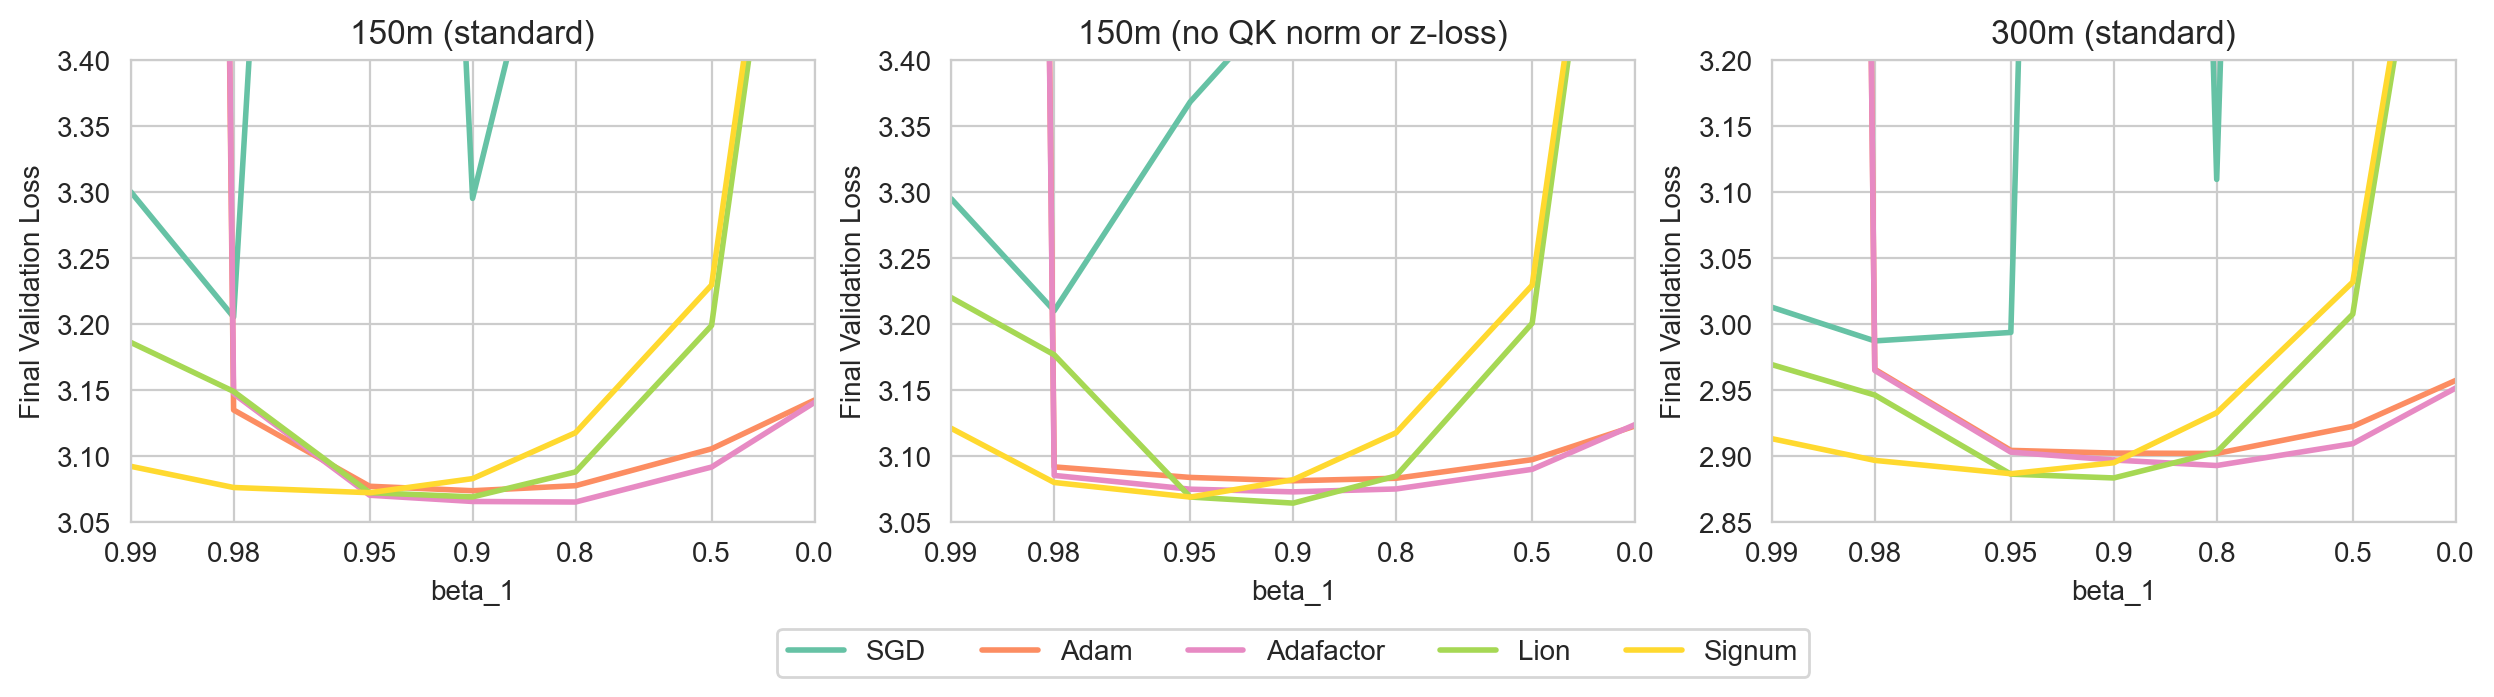

In [48]:
sns.set_style("whitegrid")
#plt.figure(figsize=(15, 3), dpi=200)  # Larger figure size
fig, axs = plt.subplots(1, 3, figsize=(15, 3), dpi=200)

for i, group in enumerate(["momentum-all-1", "momentum-noqk-1", "momentum-300-1"]):

    ax = axs[i]
    group_df = df[df["group"] == group]

    for optimizer in optimizers:
        if optimizer in ["sophiag", "novagradw_ours"]:
            continue
        if optimizer in group_df["optimizer"].unique():
            optimizer_df = group_df[group_df["optimizer"] == optimizer]
            optimizer_df = optimizer_df.sort_values(by="beta_0")
            optimizer_df = optimizer_df.groupby("beta_0").min().reset_index()
            label = name_map.get(optimizer)
            ax.plot(1 - optimizer_df["beta_0"], 
                    optimizer_df["val_loss"], 
                    label=label,
                    linewidth=2,
                    color=color_map[optimizer],
                    # linestyle='--' if optimizer in ['adamw', 'sgdw'] else '-'
            )
            # if optimizer in ["lionw"]:
            #     optimizer_df = df[(df["group"] == "beta-all-1") & (df["optimizer"] == "lionw")]
            #     optimizer_df = optimizer_df.sort_values(by="beta_1")
            #     optimizer_df = optimizer_df.groupby("beta_1").min().reset_index()
            #     label = "Lion (beta 2)"
            #     plt.plot(1 - optimizer_df["beta_1"], 
            #             optimizer_df["val_loss"], 
            #             label=label,
            #             linewidth=2,
            #             color=color_map["lionw"],
            #             linestyle=':',
            #     )


    ax.set_xscale("log")
    ax.set_xlim(0.01, 1)

    ax.set_xlabel("beta_1")
    xs = [0.0, 0.5, 0.8, 0.9, 0.95, 0.98, 0.99][::-1]

    xsa = 1 - np.array(xs)
    ax.set_xticks(xsa, xs)
    ax.set_ylabel("Final Validation Loss")
    
    
    if i == 0 or i == 1:
        ax.set_ylim(3.05, 3.4)
        if i == 0:
            ax.set_title("150m (standard)")
        else:
            ax.set_title("150m (no QK norm or z-loss)")
    else:
        ax.set_ylim(2.85, 3.2)
        ax.set_title("300m (standard)")


axs[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), fancybox=True, shadow=False, ncol=len(optimizers) )


plt.savefig('../figures/momentum_all.png', bbox_inches='tight')
plt.show()